In [247]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')

In [248]:
# Load the dataset
data = pd.read_csv('./heart.csv')

In [249]:
#top 3 rows of the dataset
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [250]:
data.shape

(918, 12)

In [251]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [252]:
data.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [253]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [254]:
data['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

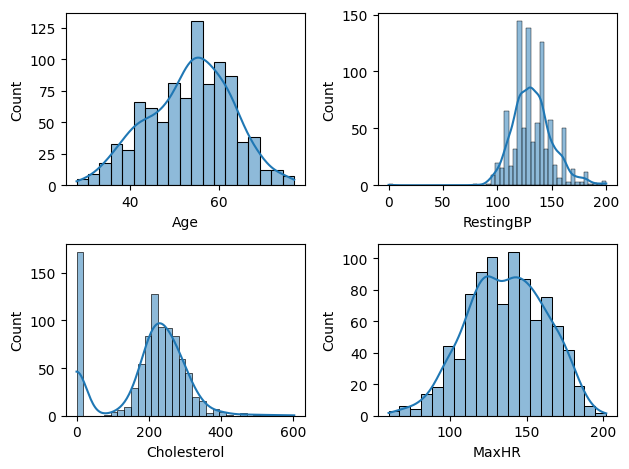

In [255]:
#  sub plots for numeric columns
def plotting(var , num):
    plt.subplot(2, 2, num)
    sns.histplot(data[var], kde=True)
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout()
plt.show()

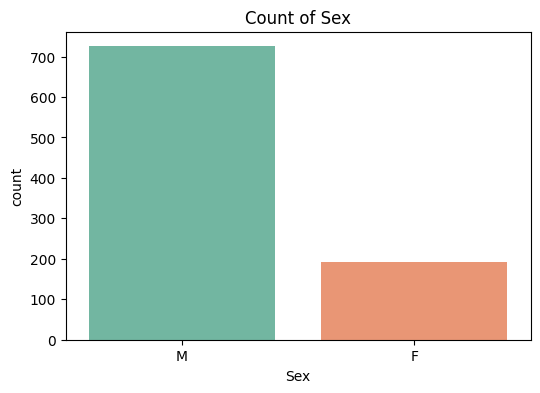

In [256]:
 #countplot for Sex column

plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=data, palette='Set2', linewidth=1.5)
plt.title('Count of Sex')
plt.show()

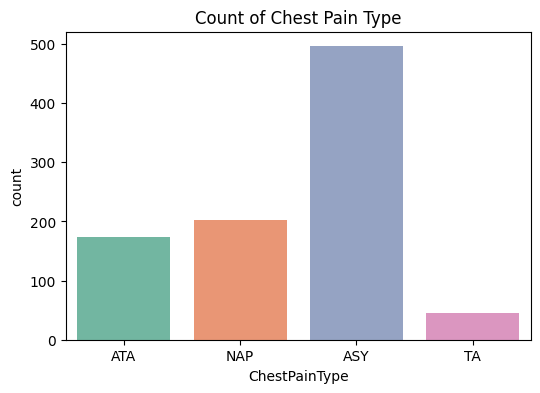

In [257]:
# countplot for ChestPainType column
plt.figure(figsize=(6, 4))
sns.countplot(x='ChestPainType', data=data, palette='Set2', linewidth=1.5) # chest pain - ATA is  asymptomatic,
# NAP is non-anginal pain,TA is typical angina, and ASY is asymptomatic
plt.title('Count of Chest Pain Type')
plt.show()

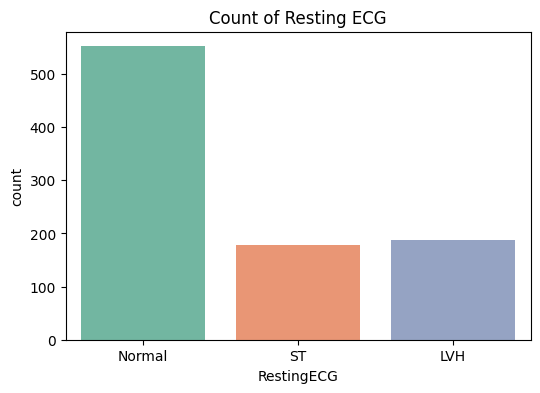

In [258]:
# countplot for RestingECG column
plt.figure(figsize=(6, 4))
sns.countplot(x='RestingECG', data=data, palette='Set2', linewidth=1.5) # resting electrocardiographic results - normal, stt abnormality, lv hypertrophy
plt.title('Count of Resting ECG')
plt.show()

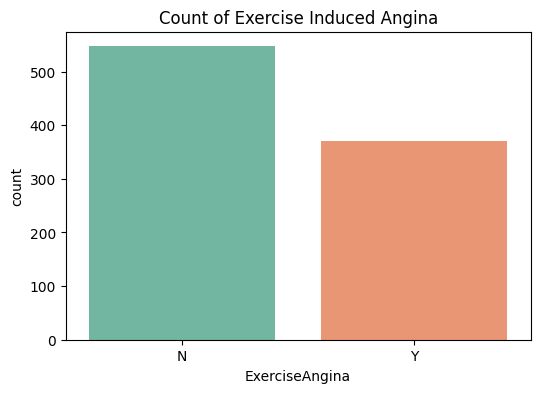

In [259]:
# countplot for ExerciseAngina column
plt.figure(figsize=(6, 4))
sns.countplot(x='ExerciseAngina', data=data, palette='Set2', linewidth=1.5) # exercise induced angina - Y is yes and N is no
plt.title('Count of Exercise Induced Angina')
plt.show()

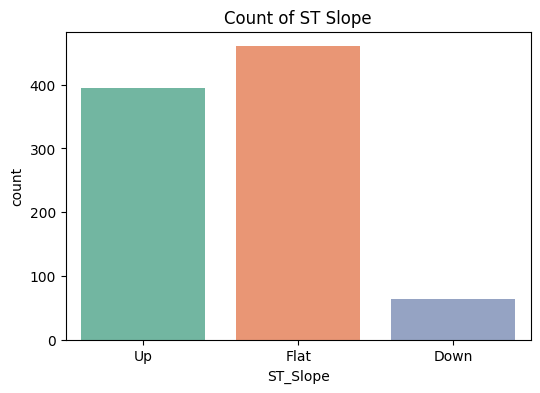

In [260]:
# countplot for ST_Slope column
plt.figure(figsize=(6, 4))
sns.countplot(x='ST_Slope', data=data, palette='Set2', linewidth=1.5) # the slope of the peak exercise ST segment - upsloping, flat, downsloping    
plt.title('Count of ST Slope')
plt.show()

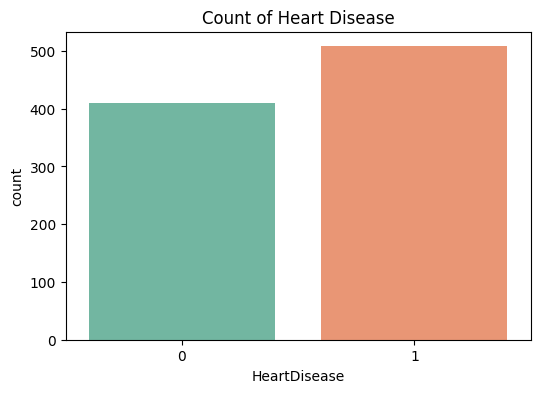

In [261]:

#count plot for HeartDisease column
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=data, palette='Set2', linewidth=1.5) # target variable - 1 is presence of heart disease and 0 is absence of heart disease
plt.title('Count of Heart Disease')
plt.show()

In [262]:

# cleaning data

import numpy as np

data['Cholesterol'] = data['Cholesterol'].replace(0, np.nan)
data['Cholesterol'].fillna(data['Cholesterol'].mean(), inplace=True)

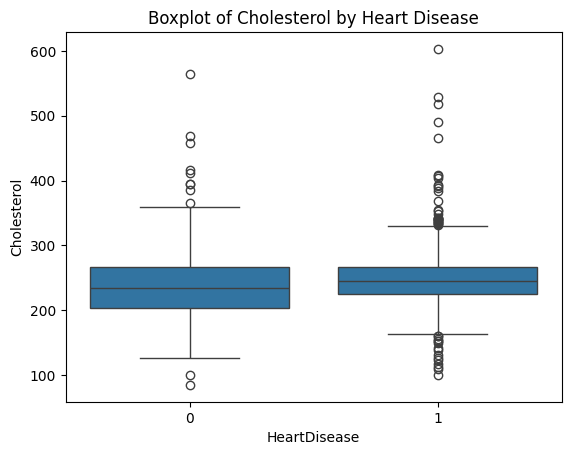

In [263]:
# boxplot for cholesterol column

sns.boxplot(x= "HeartDisease", y="Cholesterol", data=data)
plt.title('Boxplot of Cholesterol by Heart Disease')
plt.show()


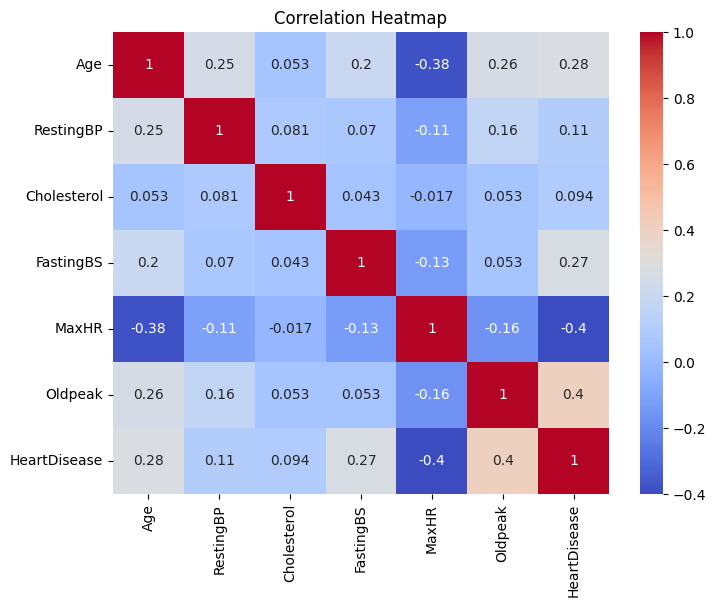

In [264]:
# heatmap for correlation of the dataset
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True) , annot=True, cmap='coolwarm')  # annot is used to display the correlation values on the heatmap
plt.title('Correlation Heatmap')
plt.show()

In [265]:
# Data preprocessing and cleaning
data_encoded = pd.get_dummies(data, drop_first=True)
data_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [266]:
data_encoded = data_encoded.astype(int)

In [267]:
data_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [268]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                918 non-null    int64
 1   RestingBP          918 non-null    int64
 2   Cholesterol        918 non-null    int64
 3   FastingBS          918 non-null    int64
 4   MaxHR              918 non-null    int64
 5   Oldpeak            918 non-null    int64
 6   HeartDisease       918 non-null    int64
 7   Sex_M              918 non-null    int64
 8   ChestPainType_ATA  918 non-null    int64
 9   ChestPainType_NAP  918 non-null    int64
 10  ChestPainType_TA   918 non-null    int64
 11  RestingECG_Normal  918 non-null    int64
 12  RestingECG_ST      918 non-null    int64
 13  ExerciseAngina_Y   918 non-null    int64
 14  ST_Slope_Flat      918 non-null    int64
 15  ST_Slope_Up        918 non-null    int64
dtypes: int64(16)
memory usage: 114.9 KB


In [269]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
data_encoded[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])

In [270]:
data_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.491752,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.129513,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.302825,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.951331,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [271]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [272]:
x = data_encoded.drop('HeartDisease', axis=1)
y = data_encoded['HeartDisease']

In [273]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [274]:
# Feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [275]:
models ={
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}


In [278]:
results = []
for name , model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "f1 Score": round(f1, 4)
    })



In [279]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.8641, 'f1 Score': 0.8804},
 {'Model': 'KNN', 'Accuracy': 0.8696, 'f1 Score': 0.8857},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8533, 'f1 Score': 0.8683},
 {'Model': 'Decision Tree', 'Accuracy': 0.788, 'f1 Score': 0.8098},
 {'Model': 'SVM', 'Accuracy': 0.8478, 'f1 Score': 0.8679}]

In [280]:
import joblib
joblib.dump(models['KNN'] , 'KNN_heart.pkl')
joblib.dump(scaler , 'scaler.pkl')
joblib.dump(x.columns.tolist(), 'columns.pkl')

['columns.pkl']